
# Guided Derivation: The Theis Equation for Unsteady Radial Flow to a Well

### Derivation using only continuity (mass conservation) + Darcy's law

This notebook walks you through deriving the [**Theis equation**](https://en.wikipedia.org/wiki/Aquifer_test), the classic 1935 solution
describing *how drawdown spreads outward from a pumping well in a confined aquifer over time*. There are a bunch of assumptions made documented on Wikipedia.
You will not need Navier–Stokes or anything beyond:

1. **Continuity** (mass/volume conservation), and
2. **Darcy's law** $q = -K\,\nabla h$, which says that the volumetric flow rate through a porous medium is proportional to the pressure drop. In groundwater modeling 'hydraulic head' h is used, and drop in head (`drawdown') is proportional to drop in pressure via $\Delta h = \frac{Delta p}{\rho g}$. A drawdown of 1 m corresponds to a pressure drop of roughly 0.1 atmospheres.

The hydraulic head is the level to which the aquifer's pressure could support water in a connected tube.

The partial differential equations reduce to a single 2nd-order ODE, which you'll solve using
**reduction of order** — a technique that turns a 2nd-order ODE into a 1st-order one.

**Structure of this notebook:**

| Part | Task | Math tools needed |
|---|---|---|
| 1 | Derive the governing PDE from a mass balance | Taylor expansion / limits |
| 2 | Introduce the similarity variable and find its derivatives | Chain rule |
| 3 | Reduce the PDE to an ODE | Algebra + chain rule (uses Part 2's results) |
| 4 | Solve the ODE by reduction of order | Separable 1st-order ODE |
| 5 | Integrate again and apply the far-field condition | Definite integrals, recognize a special function |
| 6 | Apply the well (flux) condition to fix the last constant | Limits |
| 7 | Assemble, verify, and explore the solution numerically | Plotting, asymptotics |

Run the "setup" cell below first.


In [1]:

# Setup: import what we'll need throughout the notebook
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import exp1  # the exponential integral E_1(u), aka the "well function" W(u)

sp.init_printing()

# Core symbols used throughout
r, t, S, T, Q, C1 = sp.symbols('r t S T Q C1', positive=True)
print("Setup complete.")


Setup complete.



## Part 1 — From a mass balance to a PDE

### Physical setup

A well fully penetrates a **confined aquifer** of transmissivity $T$ (units of length$^2$/time)
and storativity $S$ (dimensionless), pumping at a constant volumetric rate $Q$ starting at $t=0$.
Let $h(r,t)$ be the hydraulic head at radial distance $r$ from the well, and define the
**drawdown**

$$s(r,t) \equiv h_0 - h(r,t) \ge 0,$$

where $h_0$ is the undisturbed initial head. Flow is radially symmetric: everything depends
only on $r$ and $t$, not on angle.

Transmissivity is a measure of how much water can be transmitted horizontally through the entire thickness of an aquifer.

Storativity (or the storage coefficient) is a measure of how much water an aquifer releases from, or takes into, storage per unit surface area per unit change in head (water level).

**Darcy's law** relates the radial flux (volume per unit area per unit time) to the head gradient:

$$q_r = -K\frac{\partial h}{\partial r} = \frac{\partial s}{\partial r}\cdot\frac{T}{b}, \qquad T \equiv Kb$$

where $b$ is the aquifer thickness. The total volumetric flow rate crossing a cylindrical
surface of radius $r$ (circumference $2\pi r$, height $b$) is

$$Q(r,t) = 2\pi r b\, q_r = -2\pi r T\,\frac{\partial h}{\partial r} = 2\pi r T\,\frac{\partial s}{\partial r}.$$

Here $Q(r,t)$ is a signed flow rate, taken as positive in the outward radial direction.
Continuity enters through the shell balance below.

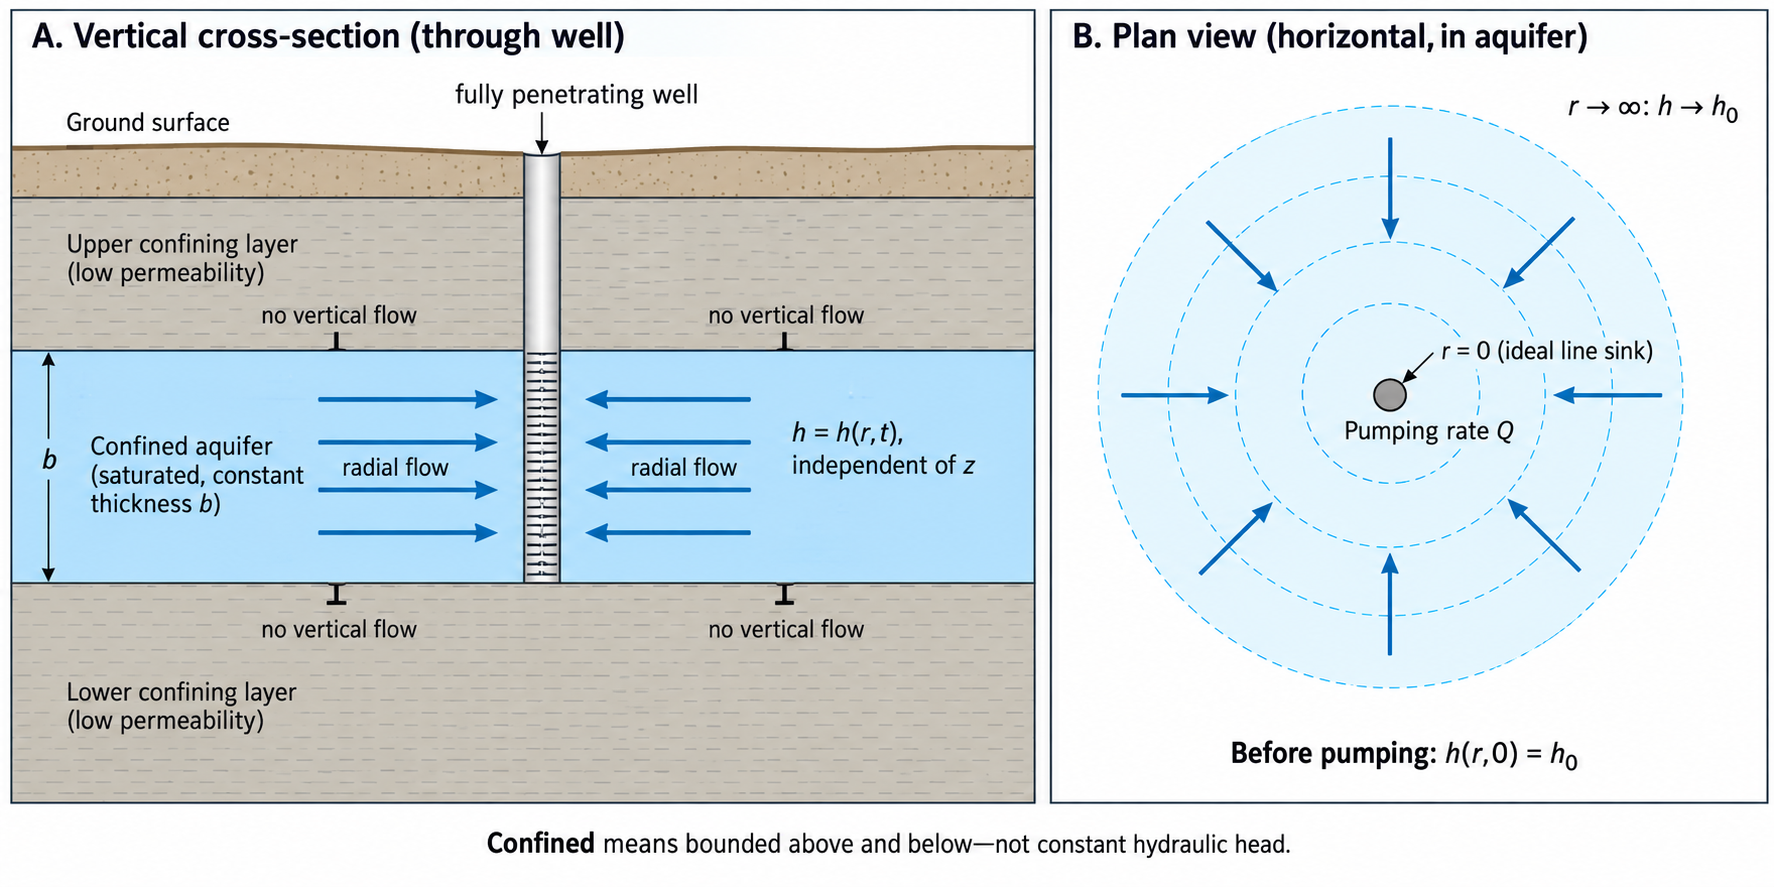

### Your task

Consider a thin cylindrical shell of the aquifer between radius $r$ and $r+dr$. Unlike the
*steady* case, flow is not conserved shell-to-shell — some water is released from **storage**
as head drops. The volume released from storage per unit time, in the shell of thickness $dr$,
is $S\cdot(2\pi r\, dr)\cdot\dfrac{\partial s}{\partial t}$ (storativity times area times rate of head drop).

**Show that** balancing (flow out) $-$ (flow in) $=$ (rate of release from storage) on this
shell, and taking the limit $dr\to 0$, gives:

$$\boxed{S\,\frac{\partial s}{\partial t} = T\left(\frac{\partial^2 s}{\partial r^2} + \frac{1}{r}\frac{\partial s}{\partial r}\right)}$$

**Hints:**
- With outward flow taken as positive, the flow crossing the inner surface is $Q(r,t)$ and
  the flow crossing the outer surface is $Q(r+dr,t)$; 
  Taylor-expand $Q(r+dr,t) \approx Q(r,t) + \dfrac{\partial Q}{\partial r}\,dr$.
- The *net outflow* from the shell is $Q(r+dr,t) - Q(r,t) \approx \dfrac{\partial Q}{\partial r}\,dr$.
- In practice, the flow crossing the inner surface inwards towards the well is greater than the flow entering the outer surface, which is also inwards.
- Set net outflow equal to the storage-release rate, divide through by $2\pi r\, dr$, and simplify
  $\dfrac{1}{r}\dfrac{\partial}{\partial r}\!\left(r\dfrac{\partial s}{\partial r}\right)$.


In [2]:

# --- Your work for Part 1 ---
# Try building the balance symbolically. Start from Q(r,t) = 2*pi*r*T*ds/dr,
# and show that (1/(2*pi*r)) * dQ/dr equals T*(s_rr + s_r/r).

s = sp.Function('s')(r, t)
Q_of_r = 2*sp.pi*r*T*sp.diff(s, r)

# Differentiate Q(r,t) with respect to r, then divide by the shell area per unit dr.
release_from_storage_per_area = sp.diff(Q_of_r, r) / (2*sp.pi*r)
release_from_storage_per_area_simplified = sp.simplify(release_from_storage_per_area)

print("Release from storage per unit shell area, per unit dr:")
sp.pprint(release_from_storage_per_area_simplified)


Release from storage per unit shell area, per unit dr:
  ⎛   2                        ⎞
  ⎜  ∂              ∂          ⎟
T⋅⎜r⋅───(s(r, t)) + ──(s(r, t))⎟
  ⎜    2            ∂r         ⎟
  ⎝  ∂r                        ⎠
────────────────────────────────
               r                



## Part 2 — The similarity variable and its derivatives

Because the aquifer is treated as infinite in extent and pumping starts abruptly at $t=0$,
there's no externally imposed length or time scale. This means $r$ and $t$ can only enter the solution through one combined variable.
Define:

$$u \equiv \frac{r^2 S}{4 T t}$$

and look for a solution of the form

$$s(r,t) = \frac{Q}{4\pi T}\,F(u)$$

for some function $F$ to be determined.

### Your task

**Show that:**

$$\text{(a)} \quad \frac{\partial u}{\partial r} = \frac{2u}{r}, \qquad
\text{(b)} \quad \frac{\partial u}{\partial t} = -\frac{u}{t}, \qquad
\text{(c)} \quad \frac{\partial^2 u}{\partial r^2} = \frac{2u}{r^2}$$



In [3]:

# --- Your work for Part 2 ---
u_expr = r**2 * S / (4*T*t)

du_dr  = sp.diff(u_expr, r)
du_dt  = sp.diff(u_expr, t)
d2u_dr2 = sp.diff(u_expr, r, 2)

print("du/dr   =", du_dr)
print("du/dt   =", du_dt)
print("d^2u/dr2 =", d2u_dr2)


du/dr   = S*r/(2*T*t)
du/dt   = -S*r**2/(4*T*t**2)
d^2u/dr2 = S/(2*T*t)


## Part 3 — Reducing the PDE to an ODE

You now have:
- The PDE: $\quad S\,\dfrac{\partial s}{\partial t} = T\left(\dfrac{\partial^2 s}{\partial r^2} + \dfrac{1}{r}\dfrac{\partial s}{\partial r}\right)$
- The ansatz: $\quad s(r,t) = \dfrac{Q}{4\pi T} F(u)$, with $u = \dfrac{r^2 S}{4Tt}$
- The derivatives of $u$: $\;\dfrac{\partial u}{\partial r} = \dfrac{2u}{r},\;\; \dfrac{\partial u}{\partial t} = -\dfrac{u}{t},\;\; \dfrac{\partial^2 u}{\partial r^2} = \dfrac{2u}{r^2}$

### Your task

Substitute everything into the PDE leaving a clean ODE purely in $u$,

$$\boxed{u\,F''(u) + (1+u)\,F'(u) = 0}$$

**Hint:** After substitution you should have an overall common factor of
$\dfrac{QS}{4\pi T t}$ multiplying everything -- divide it out. You'll also need to use
$r^2 = 4Tt\,u/S$ (from the definition of $u$) at some point to eliminate the leftover $r^2$
in the $\dfrac{\partial^2 s}{\partial r^2}$ term.

Setup: $s(r,t) = \dfrac{Q}{4\pi T}F(u)$, $;u = \dfrac{r^2S}{4Tt}$, with (from Part 2) $\dfrac{\partial u}{\partial r}=\dfrac{2u}{r}$, $\dfrac{\partial u}{\partial t}=-\dfrac{u}{t}$, $\dfrac{\partial^2 u}{\partial r^2}=\dfrac{2u}{r^2}$.

∂s/∂t (straight chain rule):
$$\frac{\partial s}{\partial t} = \frac{Q}{4\pi T}F'(u)\frac{\partial u}{\partial t} = \frac{Q}{4\pi T}F'(u)\left(-\frac{u}{t}\right) = -\frac{Qu}{4\pi T t}F'(u)$$

∂s/∂r (straight chain rule):
$$\frac{\partial s}{\partial r} = \frac{Q}{4\pi T}F'(u)\frac{\partial u}{\partial r} = \frac{Q}{4\pi T}F'(u)\left(\frac{2u}{r}\right) = \frac{Qu}{2\pi T r}F'(u)$$

∂²s/∂r² — differentiate $\dfrac{\partial s}{\partial r} = \dfrac{Q}{4\pi T}F'(u)\dfrac{\partial u}{\partial r}$ again w.r.t. $r$. This is a product of two $r$-dependent factors, so you need the product rule, and $\dfrac{d}{dr}F'(u) = F''(u)\dfrac{\partial u}{\partial r}$ by the chain rule again:

$$\frac{\partial^2 s}{\partial r^2} = \frac{Q}{4\pi T}\left[F''(u)\left(\frac{\partial u}{\partial r}\right)^2 + F'(u)\frac{\partial^2 u}{\partial r^2}\right]$$

Substituting $\dfrac{\partial u}{\partial r}=\dfrac{2u}{r}$ and $\dfrac{\partial^2 u}{\partial r^2}=\dfrac{2u}{r^2}$:

$$\frac{\partial^2 s}{\partial r^2} = \frac{Q}{4\pi T}\left[\frac{4u^2}{r^2}F''(u) + \frac{2u}{r^2}F'(u)\right] = \frac{Qu}{2\pi T r^2}\Big[2u F''(u) + F'(u)\Big]$$

Plugging all three into $S,\dfrac{\partial s}{\partial t} = T\left(\dfrac{\partial^2 s}{\partial r^2} + \dfrac{1}{r}\dfrac{\partial s}{\partial r}\right)$, the $Q$, and a factor of $u/r^2$ (using $r^2 = 4Ttu/S$) all cancel out, leaving exactly the boxed target $u F''(u) + (1+u)F'(u) = 0$ — matching what sympy computed in cell 

In [4]:

# --- Your work for Part 3 ---
# Let sympy do the chain-rule bookkeeping for you: define s as a function of u(r,t) directly.
F = sp.Function('F')
s_ansatz = Q/(4*sp.pi*T) * F(u_expr)

s_t  = sp.diff(s_ansatz, t)
s_r  = sp.diff(s_ansatz, r)
s_rr = sp.diff(s_ansatz, r, 2)

pde_lhs_minus_rhs = sp.simplify(T*(s_rr + s_r/r) - S*s_t)
print("Raw substituted PDE (should simplify nicely once r^2 = 4*T*t*u/S is used):")
sp.pprint(pde_lhs_minus_rhs)

# Introduce a clean symbol u_sym standing for u, and substitute r**2 -> 4*T*t*u_sym/S
u_sym = sp.symbols('u', positive=True)
pde_in_u = pde_lhs_minus_rhs.subs(r**2, 4*T*t*u_sym/S).subs(u_expr, u_sym)
pde_in_u_simplified = sp.simplify(pde_in_u)
print("\nAfter substituting r^2 = 4*T*t*u/S:")
sp.pprint(pde_in_u_simplified)


Raw substituted PDE (should simplify nicely once r^2 = 4*T*t*u/S is used):
    ⎛                                  ⎛  2        ⎞│                          ↪
    ⎜   2 ⎛ d        ⎞│      2       2 ⎜ d         ⎟│                 ⎛ d      ↪
Q⋅S⋅⎜S⋅r ⋅⎜───(F(ξ₁))⎟│   S⋅r   + S⋅r ⋅⎜────(F(ξ₁))⎟│      2  + 4⋅T⋅t⋅⎜───(F(ξ ↪
    ⎜     ⎝dξ₁       ⎠│ξ₁=─────        ⎜   2       ⎟│   S⋅r           ⎝dξ₁     ↪
    ⎜                     4⋅T⋅t        ⎝dξ₁        ⎠│ξ₁=─────                  ↪
    ⎝                                                   4⋅T⋅t                  ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                               2  2                            ↪
                                         16⋅π⋅T ⋅t                             ↪

↪              ⎞
↪    ⎞│      2 ⎟
↪ ₁))⎟│   S⋅r  ⎟
↪    ⎠│ξ₁=─────⎟
↪         4⋅T⋅t⎟
↪              ⎠
↪ ──────────────
↪               
↪               

After substituting r^2 = 4*T*t*u/S:
    ⎛


**Self-check for Part 3:** divide your simplified expression by the common prefactor
$\dfrac{QS}{4\pi T t}$ and compare the remainder to $u F''(u) + (1+u)F'(u)$.


In [5]:

Fu = F(u_sym)
target_ode_part3 = u_sym*sp.diff(Fu, u_sym, 2) + (1+u_sym)*sp.diff(Fu, u_sym)

prefactor = Q*S/(4*sp.pi*T*t)
my_ode_part3 = sp.simplify(pde_in_u_simplified / prefactor)

check3 = sp.simplify(my_ode_part3 - target_ode_part3)
print("Your reduced expression (after dividing out the prefactor):")
sp.pprint(my_ode_part3)
print("\nDifference from target (should be 0):", check3)
print("PASSED!" if check3 == 0 else "Not matching yet -- keep working (double-check the r^2 substitution).")


Your reduced expression (after dividing out the prefactor):
                2                  
  d            d           d       
u⋅──(F(u)) + u⋅───(F(u)) + ──(F(u))
  du             2         du      
               du                  

Difference from target (should be 0): 0
PASSED!



## Part 4 — Solving the ODE: reduction of order

*(Independent of Parts 1-3 -- you can just start from the boxed ODE below.)*

You need to solve:

$$u\,F''(u) + (1+u)\,F'(u) = 0$$

Notice this ODE has **no $F$ term at all** -- only $F'$ and $F''$ appear. This is the signal
to use **reduction of order**: substitute $p(u) \equiv F'(u)$, which turns the equation into a
*first-order* ODE for $p$.

### Your task

**Show that**, after substituting $p = F'$, the equation becomes separable, and that solving it
gives:

$$\boxed{p(u) = F'(u) = C_1\,\frac{e^{-u}}{u}}$$

for some constant of integration $C_1$.

**Hint:** you should get $\dfrac{dp}{p} = -\left(\dfrac{1}{u}+1\right)du$. Integrate both sides
and exponentiate.


In [6]:

# --- Your work for Part 4 ---
p = sp.Function('p')(u_sym)

ode_for_p = sp.Eq(u_sym*sp.diff(p, u_sym) + (1+u_sym)*p, 0)
print("ODE for p(u):")
sp.pprint(ode_for_p)

# Solve it directly (as a check on hand-work) using sympy's dsolve
p_solution = sp.dsolve(ode_for_p, p)
print("\nsympy's solution:")
sp.pprint(p_solution)


ODE for p(u):
  d                          
u⋅──(p(u)) + (u + 1)⋅p(u) = 0
  du                         

sympy's solution:
           -u
       C₁⋅ℯ  
p(u) = ──────
         u   



**Self-check for Part 4:** substitute your claimed $p(u) = C_1 e^{-u}/u$ back into the ODE
$u p' + (1+u) p = 0$ directly and confirm it's satisfied identically (for any $C_1$).


In [7]:

my_p_part4 = C1 * sp.exp(-u_sym) / u_sym

residual_part4 = sp.simplify(u_sym*sp.diff(my_p_part4, u_sym) + (1+u_sym)*my_p_part4)
print("Residual of u*p' + (1+u)*p using your p(u) (should be 0):", residual_part4)
print("PASSED!" if residual_part4 == 0 else "Not matching yet -- keep working.")


Residual of u*p' + (1+u)*p using your p(u) (should be 0): 0
PASSED!



## Part 5 — Integrating once more, and meeting a new special function

*(You can take the boxed result of Part 4 as given, even if you didn't finish it.)*

You now know $F'(u) = C_1\,e^{-u}/u$. To get $F(u)$ itself, integrate once more:

$$F(u) = C_1\int e^{-u}/u\;du + (\text{const.})$$

The **far-field condition** is $s\to 0$ as $r\to\infty$ at any fixed time $t$ -- equivalently,
$F(u)\to 0$ as $u\to\infty$.

### Your task

**Show that**, choosing the integration limits so that $F(u)\to 0$ as $u\to\infty$ is
automatically satisfied, you get:

$$F(u) = -C_1\int_u^{\infty} \frac{e^{-u'}}{u'}\,du'$$

This definite integral **cannot be written in terms of elementary functions** (polynomials,
exponentials, logs, trig). It is a named special function, the **exponential integral**:

$$E_1(u) \equiv \int_u^{\infty}\frac{e^{-t}}{t}\,dt$$

so that $\boxed{F(u) = -C_1\,E_1(u)}$.

**Hint for the "show that":** by the Fundamental Theorem of Calculus / Leibniz rule,
$\dfrac{d}{du}E_1(u) = \dfrac{d}{du}\displaystyle\int_u^\infty \dfrac{e^{-t}}{t}dt = -\dfrac{e^{-u}}{u}$
(differentiating with respect to the *lower* limit brings down a minus sign). So
$F(u) = -C_1 E_1(u)$ gives $F'(u) = -C_1\cdot\left(-\dfrac{e^{-u}}{u}\right) = C_1\dfrac{e^{-u}}{u}$,
which matches Part 4 exactly. Separately, confirm $E_1(u)\to 0$ as $u\to\infty$ (the integral of
a rapidly-decaying integrand from $u$ to $\infty$ vanishes as the lower limit moves to
$\infty$), so $F(u)\to 0$ there too, as required.


In [8]:

# --- Your work for Part 5 ---
# 1) Confirm E_1(u) really does have derivative e^{-u}/u using sympy's built-in Ei-related function.
u_pos = sp.symbols('u', positive=True)
E1_expr = sp.Function('E1')  # symbolic placeholder; sympy calls this "expint(1, u)"

E1_sympy = sp.expint(1, u_pos)   # sympy's built-in exponential integral E_1(u)
derivative_of_E1 = sp.diff(E1_sympy, u_pos)
print("d/du [E_1(u)] computed by sympy:")
sp.pprint(sp.simplify(derivative_of_E1))
print("(should be -e^{-u}/u; note the minus sign -- this is why F(u) = -C1*E_1(u),")
print(" not +C1*E_1(u), is what reproduces F'(u) = C1*e^{-u}/u from Part 4)")

# 2) Confirm the limit as u -> infinity is 0
limit_at_infinity = sp.limit(E1_sympy, u_pos, sp.oo)
print("\nlimit of E_1(u) as u -> infinity:", limit_at_infinity)


d/du [E_1(u)] computed by sympy:
  -u 
-ℯ   
─────
  u  
(should be -e^{-u}/u; note the minus sign -- this is why F(u) = -C1*E_1(u),
 not +C1*E_1(u), is what reproduces F'(u) = C1*e^{-u}/u from Part 4)

limit of E_1(u) as u -> infinity: expint(1, oo)



**Self-check for Part 5:** verify that $\dfrac{d}{du}\big[-C_1 E_1(u)\big]$ equals your Part 4
answer $C_1 e^{-u}/u$, confirming $F(u) = -C_1 E_1(u)$ is consistent with everything so far.


In [9]:

my_F_part5 = -C1 * sp.expint(1, u_sym)
dF_du = sp.diff(my_F_part5, u_sym)

check5 = sp.simplify(dF_du - my_p_part4)
print("Difference between d/du[F(u)] and your Part 4 result for p(u) (should be 0):", check5)
print("PASSED!" if check5 == 0 else "Not matching yet -- keep working.")


Difference between d/du[F(u)] and your Part 4 result for p(u) (should be 0): 0
PASSED!


## Part 6 — Applying the well condition to fix $C_1$

*(You can take $F(u) = -C_1 E_1(u)$ as given, even if you didn't finish Part 5 by hand.)*

There's one constant left: $C_1$. It's fixed by the physical requirement that the flux at the
well bore matches the pumping rate $Q$. Since the well *extracts* water, drawdown $s$ must
*decrease* outward from the well ($s$ is largest at the well, zero far away), so
$\partial s/\partial r < 0$ everywhere. Darcy's law applied right at the well bore gives the
**well condition**:

$$\lim_{r\to 0}\left(r\,\frac{\partial s}{\partial r}\right) = -\frac{Q}{2\pi T}$$

(the minus sign is exactly what enforces $s$ decreasing outward; you can check this same sign
convention reproduces the correct, increasing-outward $h(r)=\frac{Q}{2\pi T}\ln r + \text{const}$
of the steady Thiem solution once you write $s = -( h-h_0)$).

### Your task

Recall $s = \dfrac{Q}{4\pi T}F(u)$ and $\dfrac{\partial u}{\partial r} = \dfrac{2u}{r}$, so

$$r\,\frac{\partial s}{\partial r} = \frac{Q}{4\pi T}\,F'(u)\cdot r\cdot\frac{2u}{r} = \frac{Q}{2\pi T}\,u\,F'(u)$$

**Show that**, using $F'(u) = C_1 e^{-u}/u$ from Part 4, taking $r\to 0$ (equivalently $u\to 0$,
since $u\propto r^2$) gives:

$$\lim_{u\to 0}\big[u\,F'(u)\big] = C_1$$

and therefore, matching to the well condition $\dfrac{Q}{2\pi T}\cdot C_1 = -\dfrac{Q}{2\pi T}$
forces

$$\boxed{C_1 = -1}$$

Substituting back into $F(u) = -C_1 E_1(u)$ from Part 5, this finally gives the clean result
$F(u) = E_1(u)$ -- the two minus signs (one from the well condition, one from the Part 5
integration) cancel, which is why the final formula below has no leftover minus sign anywhere.

In [10]:

# --- Your work for Part 6 ---
uF_prime = sp.simplify(u_sym * my_p_part4)   # u * F'(u), using p(u) = F'(u) from Part 4
print("u * F'(u) =", uF_prime)

limit_as_u_to_0 = sp.limit(uF_prime, u_sym, 0)
print("limit as u -> 0:", limit_as_u_to_0)


u * F'(u) = C1*exp(-u)
limit as u -> 0: C1


**Self-check for Part 6:** confirm that the limit you computed equals $C_1$ exactly (not, say,
$2C_1$ or $C_1/2$ -- a common place to lose a factor of 2 is in the $\dfrac{\partial u}{\partial r} = \dfrac{2u}{r}$ step).

In [11]:

check6 = sp.simplify(limit_as_u_to_0 - C1)
print("Difference between your limit and C1 (should be 0):", check6)
print("PASSED!" if check6 == 0 else "Not matching yet -- double check the factor of 2 from u_r = 2u/r.")


Difference between your limit and C1 (should be 0): 0
PASSED!



## Part 7 — Assembling and exploring the Theis solution

Putting it all together, with $C_1 = -1$ (so that $F(u) = -C_1 E_1(u) = E_1(u)$):

$$\boxed{s(r,t) = \frac{Q}{4\pi T}\,W(u), \qquad u = \frac{r^2 S}{4Tt}, \qquad W(u) \equiv E_1(u) = \int_u^\infty \frac{e^{-t}}{t}\,dt}$$

$W(u)$ is called the **well function** in hydrogeology -- it's exactly $E_1(u)$ wearing a
field-specific name. This is the **Theis equation** (1935), the standard tool for interpreting
pumping-test data in confined aquifers.

### Task A -- sanity checks

**Show that** the solution behaves correctly in the two limits:
- As $u \to \infty$ (very early times, or far from the well): $W(u) \to 0$, so $s \to 0$
  (undisturbed aquifer) -- consistent with the initial condition.
- As $u \to 0$ (very late times, or right at the well): $W(u) \to \infty$, so drawdown grows
  without bound at $r=0$ -- reflecting the idealization of an infinitesimally thin well.

### Task B -- the Cooper-Jacob approximation

For small $u$ (late times / near the well), it's known that

$$W(u) \approx -\gamma - \ln u, \qquad \gamma \approx 0.5772 \text{ (Euler-Mascheroni constant)}$$

**Show that** this approximation follows from the general small-argument behavior of the
exponential integral (`sympy` can give you the series expansion directly), and plot it against
the exact $W(u)$ to see over what range of $u$ it's a good approximation.

### Task C -- compute and plot drawdown curves

Using realistic aquifer parameters, compute and plot $s(r,t)$ vs. $r$ at a few different times,
and also $s(r,t)$ vs. $t$ at a few different radii.


In [12]:

# Task A: sanity checks
u_check = sp.symbols('u', positive=True)
lim_inf = sp.limit(sp.expint(1, u_check), u_check, sp.oo)
lim_0   = sp.limit(sp.expint(1, u_check), u_check, 0, dir='+')
print("W(u) as u -> infinity:", lim_inf)
print("W(u) as u -> 0:       ", lim_0)


W(u) as u -> infinity: expint(1, oo)
W(u) as u -> 0:        oo


In [13]:

# Task B: Cooper-Jacob small-u approximation, straight from the series expansion of E_1(u)
series_expansion = sp.series(sp.expint(1, u_check), u_check, 0, 2)
print("Series expansion of W(u) = E1(u) near u = 0:")
sp.pprint(series_expansion)
print("\nCompare to the claimed Cooper-Jacob form: -gamma - ln(u)")
print("Euler-Mascheroni constant, gamma =", float(sp.EulerGamma))


Series expansion of W(u) = E1(u) near u = 0:
                   ⎛ 2⎞
-γ - log(u) + u + O⎝u ⎠

Compare to the claimed Cooper-Jacob form: -gamma - ln(u)
Euler-Mascheroni constant, gamma = 0.5772156649015329


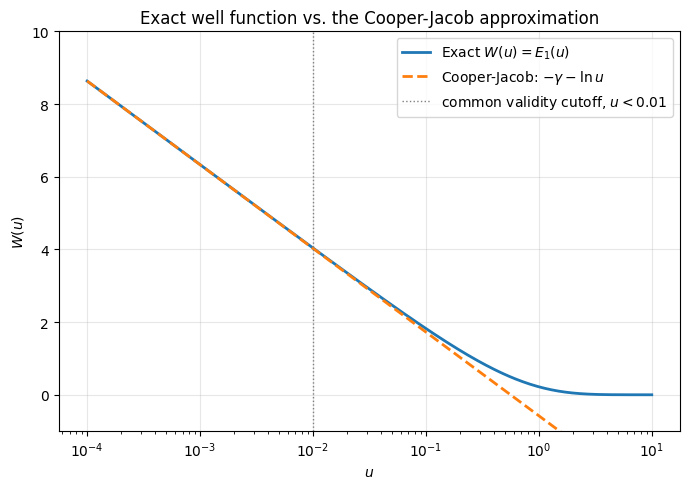

In [14]:

# Plot exact W(u) vs the Cooper-Jacob approximation
u_vals = np.logspace(-4, 1, 400)
W_exact = exp1(u_vals)                                  # scipy's exponential integral E1
gamma = 0.5772156649
W_cooper_jacob = -gamma - np.log(u_vals)

plt.figure(figsize=(7,5))
plt.semilogx(u_vals, W_exact, label='Exact $W(u) = E_1(u)$', lw=2)
plt.semilogx(u_vals, W_cooper_jacob, '--', label='Cooper-Jacob: $-\\gamma - \\ln u$', lw=2)
plt.axvline(0.01, color='gray', ls=':', lw=1, label='common validity cutoff, $u<0.01$')
plt.xlabel('$u$')
plt.ylabel('$W(u)$')
plt.title('Exact well function vs. the Cooper-Jacob approximation')
plt.legend()
plt.ylim(-1, 10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


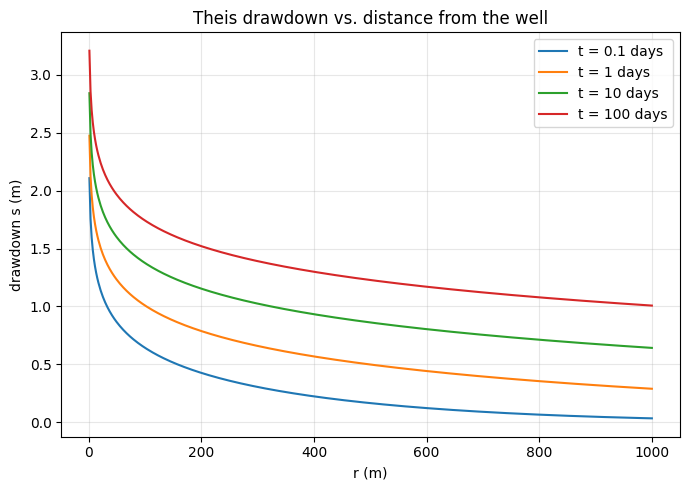

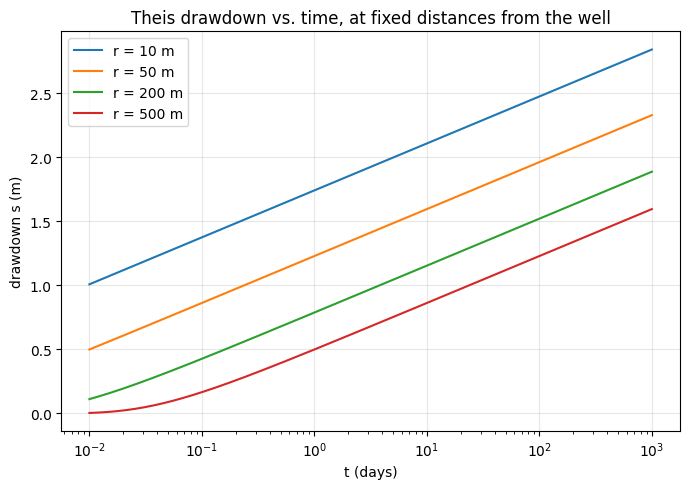

In [15]:

# Task C: drawdown curves for realistic aquifer parameters
S_val = 2.0e-4      # storativity (dimensionless)
T_val = 500.0       # transmissivity, m^2/day
Q_val = 1000.0      # pumping rate, m^3/day

def theis_drawdown(r_val, t_val, S_val=S_val, T_val=T_val, Q_val=Q_val):
    u_val = (r_val**2 * S_val) / (4 * T_val * t_val)
    return (Q_val / (4*np.pi*T_val)) * exp1(u_val)

# (i) Drawdown vs radius, at several times
r_range = np.linspace(1, 1000, 500)
plt.figure(figsize=(7,5))
for t_val in [0.1, 1, 10, 100]:
    s_vals = theis_drawdown(r_range, t_val)
    plt.plot(r_range, s_vals, label=f't = {t_val} days')
plt.xlabel('r (m)')
plt.ylabel('drawdown s (m)')
plt.title('Theis drawdown vs. distance from the well')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# (ii) Drawdown vs time, at several radii
t_range = np.logspace(-2, 3, 500)
plt.figure(figsize=(7,5))
for r_val in [10, 50, 200, 500]:
    s_vals = theis_drawdown(r_val, t_range)
    plt.semilogx(t_range, s_vals, label=f'r = {r_val} m')
plt.xlabel('t (days)')
plt.ylabel('drawdown s (m)')
plt.title('Theis drawdown vs. time, at fixed distances from the well')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


---
## Summary

**Part 1:**
$$S\,\frac{\partial s}{\partial t} = T\left(\frac{\partial^2 s}{\partial r^2} + \frac{1}{r}\frac{\partial s}{\partial r}\right)$$

**Part 2:** with $u = \dfrac{r^2 S}{4Tt}$,
$$\frac{\partial u}{\partial r} = \frac{2u}{r}, \qquad \frac{\partial u}{\partial t} = -\frac{u}{t}, \qquad \frac{\partial^2 u}{\partial r^2} = \frac{2u}{r^2}$$

**Part 3:**
$$u\,F''(u) + (1+u)\,F'(u) = 0$$

**Part 4:** with $p = F'$,
$$\frac{dp}{p} = -\left(\frac{1}{u}+1\right)du \;\;\Rightarrow\;\; p(u) = F'(u) = C_1\frac{e^{-u}}{u}$$

**Part 5:**
$$F(u) = -C_1\int_u^\infty \frac{e^{-u'}}{u'}\,du' = -C_1\,E_1(u)$$

**Part 6:** matching $\lim_{r\to0}\left(r\,\partial s/\partial r\right) = -Q/(2\pi T)$ gives
$$C_1 = -1 \quad\Rightarrow\quad F(u) = E_1(u)$$

**Part 7 (final result):**
$$s(r,t) = \frac{Q}{4\pi T}\,W(u), \qquad u = \frac{r^2 S}{4Tt}, \qquad W(u) = E_1(u)$$

This is the **Theis equation**, the basis for aquifer flow models to describe how water moves underground. 